## Paddy Disease Classification with MobileNet
This notebook demonstrates a transfer learning approach to classify rice paddy diseases using the MobileNet architecture.

### Dataset Exploration

In [2]:
import glob
from pathlib import Path

train_path = r"/kaggle/input/Augmented and split - 26000 augmented images split into train (80) sets/train/"
test_path  = r"/kaggle/input/Augmented and split - 26000 augmented images split into train (80) sets/test/"

print('train images')
for filepath in glob.glob(train_path + '/*/'):
    files = glob.glob(filepath + '*')
    print(f"{len(files)} \t {Path(filepath).name}")
    
print('test images')
for filepath in glob.glob(test_path + '/*/'):
    files = glob.glob(filepath + '*')
    print(f"{len(files)} \t {Path(filepath).name}")

train images
1600 	 tungro
1600 	 yellow_stem_borer
1600 	 hispa
1601 	 downy_mildew
1600 	 black_stem_borer
1600 	 bacterial_leaf_streak
1599 	 bacterial_leaf_blight
1601 	 brown_spot
1600 	 blast
1600 	 leaf_roller
1599 	 normal
1599 	 bacterial_panicle_blight
1601 	 white_stem_borer
test images
400 	 tungro
400 	 yellow_stem_borer
400 	 hispa
399 	 downy_mildew
400 	 black_stem_borer
400 	 bacterial_leaf_streak
401 	 bacterial_leaf_blight
399 	 brown_spot
400 	 blast
400 	 leaf_roller
401 	 normal
401 	 bacterial_panicle_blight
399 	 white_stem_borer


## Import Libraries and Set Configuration

This cell imports necessary libraries and sets up the configuration parameters for the model training process.

In [3]:
import numpy as np
import pandas as pd
import pickle
import cv2
import os
import glob
from os import listdir
from sklearn.preprocessing import LabelBinarizer
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Activation, Flatten, Dropout, Dense
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import img_to_array
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import psutil

print(f"TensorFlow version: {keras.__version__}")

SEED = 123
EPOCHS = 100
INIT_LR = 1e-3
BS = 32
default_image_size = tuple((256, 256))
image_size = 0
width = 256
height = 256
depth = 3

# Make sure train_path is defined before using it
n_classes = len(glob.glob(train_path + '/*/'))
print(f"Number of classes: {n_classes}")

# Display available memory
mem = psutil.virtual_memory()
print(f"Available memory: {mem.available / (1024 ** 3):.2f} GB")

2025-04-21 10:39:29.001051: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745231969.311001      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745231969.394083      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow version: 3.5.0
Number of classes: 13
Available memory: 29.65 GB


## Define MobileNet Transfer Learning Model Architecture
This function creates a MobileNet-based model with transfer learning for disease classification. The pre-trained MobileNet architecture is used as a feature extractor with custom classification layers on top.

In [4]:
import os
import numpy as np
from pathlib import Path
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.mobilenet import MobileNet, preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, Flatten

def create_model_mobilenet(input_shape, n_classes, optimizer='rmsprop', fine_tune=0):
    """
    Compiles a model integrated with MobileNet pretrained layers
    
    input_shape: tuple - the shape of input images (width, height, channels)
    n_classes: int - number of classes for the output layer
    optimizer: string or optimizer instance - optimizer to use for training
    fine_tune: int - The number of pre-trained layers to unfreeze.
                If set to 0, all pretrained layers will freeze during training
    """
    
    # Pretrained convolutional layers are loaded using the Imagenet weights.
    # Include_top is set to False, in order to exclude the model's fully-connected layers.
    conv_base = MobileNet(include_top=False,
                     weights='imagenet', 
                     input_shape=input_shape)
    
    # Defines how many layers to freeze during training.
    # Layers in the convolutional base are switched from trainable to non-trainable
    # depending on the size of the fine-tuning parameter.
    if fine_tune > 0:
        for layer in conv_base.layers[:-fine_tune]:
            layer.trainable = False
    else:
        for layer in conv_base.layers:
            layer.trainable = False
            
    # Create a new 'top' of the model (i.e. fully-connected layers).
    # This is 'bootstrapping' a new top_model onto the pretrained layers.
    top_model = conv_base.output
    top_model = Flatten(name="flatten")(top_model)
    top_model = Dense(1024, activation='relu')(top_model)
    top_model = Dropout(0.2)(top_model)
    
    output_layer = Dense(n_classes, activation='softmax')(top_model)
    
    # Group the convolutional base and new fully-connected layers into a Model object.
    model = Model(inputs=conv_base.input, outputs=output_layer)
    
    # Compiles the model for training.
    model.compile(optimizer=optimizer, 
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    
    return model

# Define input shape
input_shape = (256, 256, 3)

# Use a smaller learning rate (note: the 'lr' parameter is now deprecated in newer versions,
# use 'learning_rate' instead)
optim_2 = Adam(learning_rate=0.0001)

# Make sure n_classes is defined before using it
# If not defined elsewhere, uncomment and set the number of classes:
# n_classes = your_number_of_classes  

# Re-compile the model, this time leaving the last 24 layers unfrozen for Fine-Tuning
model = create_model_mobilenet(input_shape, n_classes, optim_2, fine_tune=24)
model.summary()

I0000 00:00:1745231983.431102      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1745231983.431835      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/tmp/ipykernel_31/291076900.py:25: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  conv_base = MobileNet(include_top=False,


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1 (Conv2D)                       │ (None, 128, 128, 32)        │             864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1_bn (BatchNormalization)        │ (None, 128, 128, 32)        │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1_relu (ReLU)                    │ (None, 128, 128, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_1 (DepthwiseConv2D)          │ (None, 128, 128, 32)        │             288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_1_bn (BatchNormalization)    │ (None, 128, 128, 32)        │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_1_relu (ReLU)                │ (None, 128, 128, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_1 (Conv2D)                   │ (None, 128, 128, 64)        │           2,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_1_bn (BatchNormalization)    │ (None, 128, 128, 64)        │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_1_relu (ReLU)                │ (None, 128, 128, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pad_2 (ZeroPadding2D)           │ (None, 129, 129, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_2 (DepthwiseConv2D)          │ (None, 64, 64, 64)          │             576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_2_bn (BatchNormalization)    │ (None, 64, 64, 64)          │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_2_relu (ReLU)                │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_2 (Conv2D)                   │ (None, 64, 64, 128)         │           8,192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_2_bn (BatchNormalization)    │ (None, 64, 64, 128)         │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_2_relu (ReLU)                │ (None, 64, 64, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_3 (DepthwiseConv2D)          │ (None, 64, 64, 128)         │           1,152 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_3_bn (BatchNormalization)    │ (None, 64, 64, 128)         │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_dw_3_relu (ReLU)                │ (None, 64, 64, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_pw_3 (Conv2D)                   │ (None, 64, 64, 128)         │          16,384 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 70,352,077 (268.37 MB)

 Trainable params: 69,250,061 (264.17 MB)

 Non-trainable params: 1,102,016 (4.20 MB)

## Configure Data Generators
Set up data generators for training, validation, and testing with appropriate augmentation settings to increase the diversity of training examples.

In [5]:
image_datagen = ImageDataGenerator(featurewise_center=False,
                 samplewise_center=False,
                 featurewise_std_normalization=False,
                 samplewise_std_normalization=False,
                 zca_whitening=False,
                 rotation_range=5,
                 shear_range=0.2,
                 zoom_range=0.2,
                 width_shift_range=0.05,
                 height_shift_range=0.05,
                 channel_shift_range=0.,
                 fill_mode='nearest',
                 horizontal_flip=True,
                 vertical_flip=False,
                 rescale=1./255,
                                   validation_split=0.2)

train_generator = image_datagen.flow_from_directory(    
    directory = train_path,
    subset='training',
    target_size=(256, 256),
    color_mode="rgb",
    batch_size=32,
    class_mode="categorical",
    shuffle=True,
    seed=SEED)

valid_generator = image_datagen.flow_from_directory(    
    directory=train_path,
    subset='validation',
    target_size=(256, 256),
    color_mode="rgb",
    batch_size=32,
    class_mode="categorical",
    shuffle=True,
    seed=SEED)

test_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(    
    directory=test_path,
    target_size=(256, 256),
    color_mode="rgb",
    batch_size=1,
    classes=['.'],
    class_mode=None,
    shuffle=False,
    seed=SEED)

print(train_generator.class_indices)
print(test_generator.samples)

Found 16643 images belonging to 13 classes.
Found 4157 images belonging to 13 classes.
Found 5200 images belonging to 1 classes.
{'bacterial_leaf_blight': 0, 'bacterial_leaf_streak': 1, 'bacterial_panicle_blight': 2, 'black_stem_borer': 3, 'blast': 4, 'brown_spot': 5, 'downy_mildew': 6, 'hispa': 7, 'leaf_roller': 8, 'normal': 9, 'tungro': 10, 'white_stem_borer': 11, 'yellow_stem_borer': 12}
5200


## Set Up Callbacks for Model Training
Define callbacks for live loss visualization, model checkpointing, and early stopping to monitor and improve the training process.

In [6]:
try:
    from livelossplot.inputs.keras import PlotLossesCallback
except: 
    !pip install livelossplot
    from livelossplot.inputs.keras import PlotLossesCallback

# Initialize livelossplot callback
plot_loss_1 = PlotLossesCallback()

# ModelCheckpoint callback - save complete model
# Using .keras extension as required by newer Keras versions
tl_checkpoint_1 = ModelCheckpoint(
    filepath='model/mobilenet_model.best.keras',
    save_best_only=True,
    verbose=1
)

# If you specifically need to save only weights
# Use save_weights_only=True with the required .weights.h5 extension
weights_checkpoint = ModelCheckpoint(
    filepath='model/mobilenet_model.weights.h5',  # Must end with .weights.h5 for weights-only
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

# EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    mode='min'
)

## Configure Weights & Biases Integration
Set up Weights & Biases (wandb) for experiment tracking and logging training metrics.

In [7]:
import wandb
from tensorflow.keras.callbacks import Callback

# Login to wandb with your API key
wandb.login(key="f54d876ebca391d5a1ed3eebb7a43aa7bea9da21")

# Initialize a wandb run
run = wandb.init(
    project="project-ablations",
    name="mobilenet-augmented",
    config={
        "epochs": EPOCHS,
        "batch_size": BS,
        "learning_rate": INIT_LR,
        "fine_tune_layers": 24,
        "architecture": "MobileNet Transfer Learning"
    }
)

# Create a custom wandb callback that avoids the graph error
class CustomWandbCallback(Callback):
    def __init__(self, monitor='val_loss', mode='auto', save_model=False):
        super(CustomWandbCallback, self).__init__()
        self.monitor = monitor
        self.mode = mode
        self.save_model = save_model
        self.best = float('inf') if mode == 'min' else float('-inf')
        
    def on_epoch_end(self, epoch, logs=None):
        # Log metrics at the end of each epoch
        if logs:
            wandb.log(logs, step=epoch)
            
            # Save model if it's the best so far
            if self.save_model:
                current = logs.get(self.monitor)
                if current is not None:
                    if (self.mode == 'min' and current < self.best) or \
                       (self.mode == 'max' and current > self.best):
                        self.best = current
                        self.model.save(f'model-best-{self.monitor}-{current:.4f}.keras')
                        wandb.save(f'model-best-{self.monitor}-{current:.4f}.keras')

# Create the custom callback that will work with your TensorFlow version
wandb_callback = CustomWandbCallback(
    monitor="val_accuracy",
    mode="max",
    save_model=False
)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nigibril1 (nigibril1-gibril-tech) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


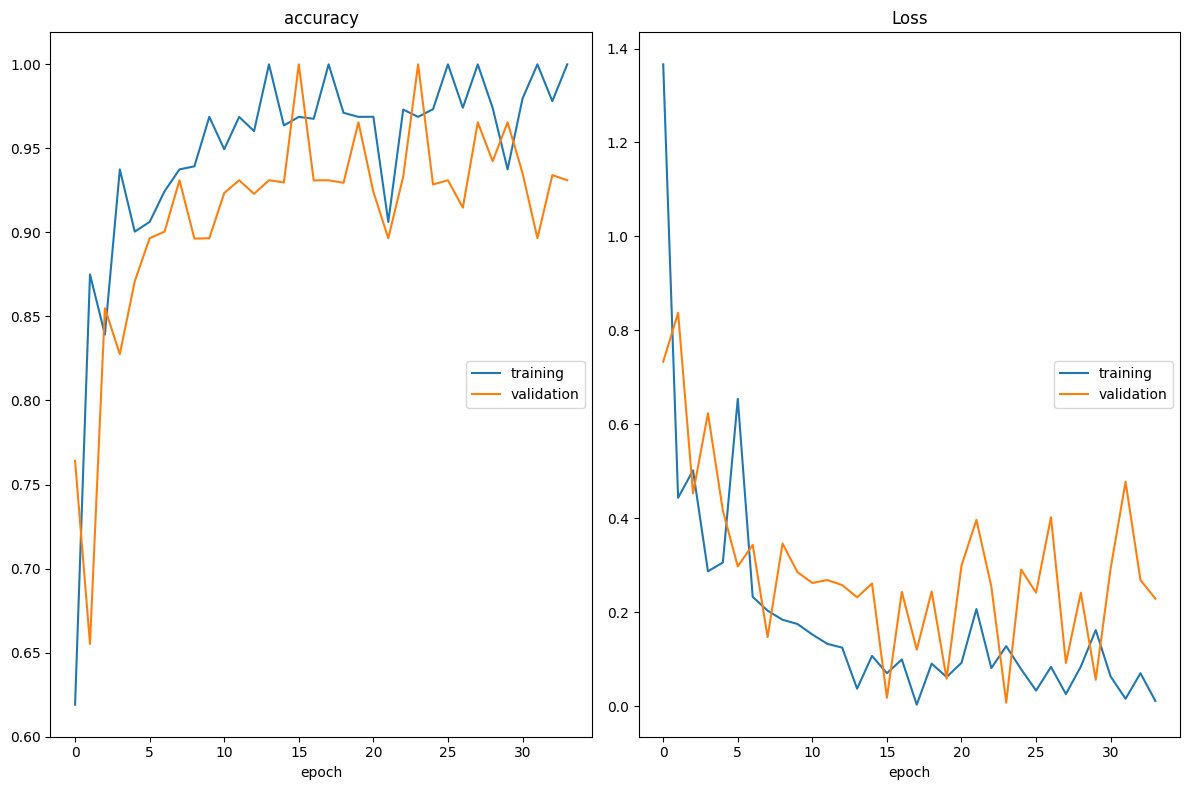

accuracy
	training         	 (min:    0.619, max:    1.000, cur:    1.000)
	validation       	 (min:    0.655, max:    1.000, cur:    0.931)
Loss
	training         	 (min:    0.003, max:    1.366, cur:    0.011)
	validation       	 (min:    0.007, max:    0.838, cur:    0.229)
520/520 ━━━━━━━━━━━━━━━━━━━━ 1s 891us/step - accuracy: 1.0000 - loss: 0.0108 - val_accuracy: 0.9310 - val_loss: 0.2288
CPU times: user 2h 35min 44s, sys: 1min 14s, total: 2h 36min 58s
Wall time: 1h 26min 14s


In [8]:
%%time
# Initialize the loss plotting callback
plot_loss_2 = PlotLossesCallback()

# Calculate steps per epoch
STEP_SIZE_TRAIN = train_generator.n // train_generator.batch_size
STEP_SIZE_VALID = valid_generator.n // valid_generator.batch_size

# Retrain model with fine-tuning
# Use fit() instead of fit_generator() which is deprecated
history = model.fit(
    train_generator,
    steps_per_epoch=STEP_SIZE_TRAIN,
    validation_data=valid_generator,
    validation_steps=STEP_SIZE_VALID,
    callbacks=[tl_checkpoint_1, early_stop, plot_loss_2, wandb_callback],
    verbose=1,
    epochs=EPOCHS
)

## Visualize Training History
Plot training metrics to visualize model performance over epochs.

Keys in history: dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])
Lengths of arrays:
accuracy: 34
loss: 34
val_accuracy: 34
val_loss: 34
Minimum length: 34


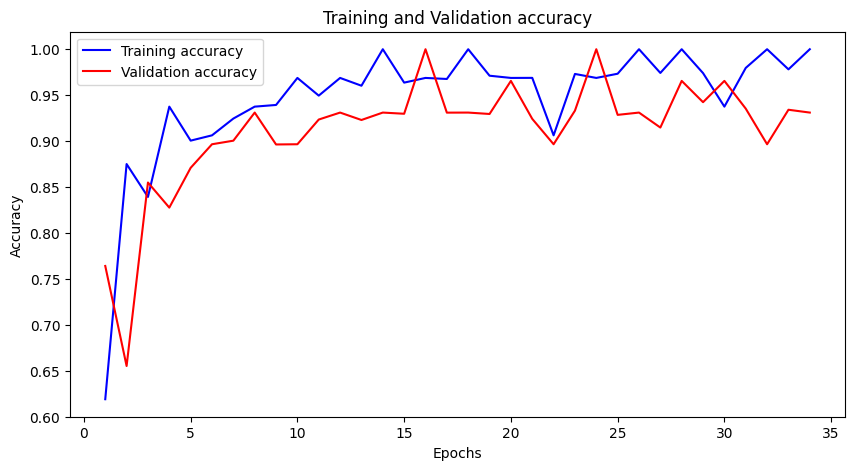

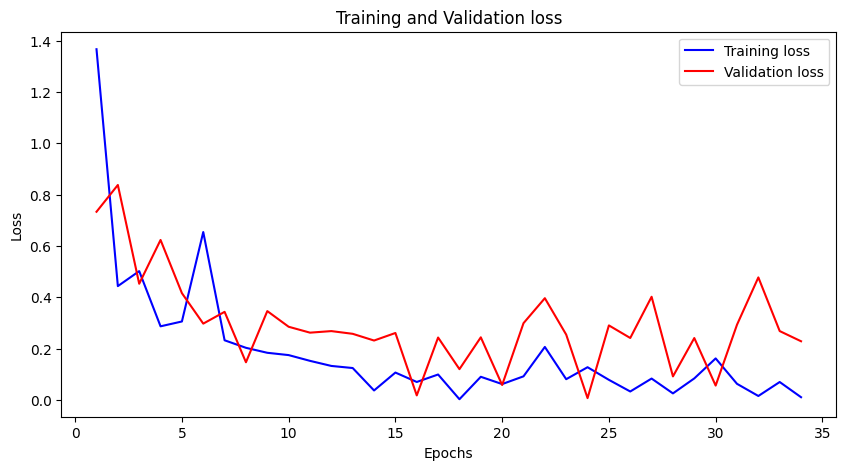

CPU times: user 367 ms, sys: 9 ms, total: 376 ms
Wall time: 373 ms


In [12]:
%%time
# Check the structure of history.history
print("Keys in history:", history.history.keys())
print("Lengths of arrays:")
for key in history.history:
    print(f"{key}: {len(history.history[key])}")

# Make sure all arrays are the same length
min_length = min(len(history.history[key]) for key in history.history)
print(f"Minimum length: {min_length}")

# Create a consistent history dictionary
consistent_history = {}
for key in history.history:
    consistent_history[key] = history.history[key][:min_length]

# Now create the DataFrame
temp = pd.DataFrame(consistent_history)
temp.to_csv('model_mobilenet_history.csv', index=False)

# Extract metrics for plotting
acc = consistent_history['accuracy']
val_acc = consistent_history['val_accuracy'] 
loss = consistent_history['loss']
val_loss = consistent_history['val_loss']
epochs = range(1, len(acc) + 1)

# Create figure 1: Accuracy
plt.figure(figsize=(10, 5))
plt.plot(epochs, acc, 'b', label='Training accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation accuracy')
plt.title('Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Create figure 2: Loss
plt.figure(figsize=(10, 5))
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

## Prepare Test Data Generator
Set up the test data generator for model evaluation.

In [13]:
print('test images')
for filepath in glob.glob(test_path + '/*/'):
    files = glob.glob(filepath + '*')
    print(f"{len(files)} \t {Path(filepath).name}")
    
test_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(    
    directory=test_path,
    target_size=(256, 256),
    color_mode="rgb",
    batch_size=1,
    #classes=['.'],
    #class_mode="categorical",
    class_mode=None,
    shuffle=False,
    seed=SEED)

test images
400 	 tungro
400 	 yellow_stem_borer
400 	 hispa
399 	 downy_mildew
400 	 black_stem_borer
400 	 bacterial_leaf_streak
401 	 bacterial_leaf_blight
399 	 brown_spot
400 	 blast
400 	 leaf_roller
401 	 normal
401 	 bacterial_panicle_blight
399 	 white_stem_borer
Found 5200 images belonging to 13 classes.


## Run Model Predictions on Test Data
Generate predictions on the test dataset using the best trained model.

In [15]:
STEP_SIZE_TEST = test_generator.n // test_generator.batch_size
test_generator.reset()

# Load the best model with the highest validation accuracy
best_model_path = '/kaggle/working/model/mobilenet_model.best.keras'
print(f"Loading best model from: {best_model_path}")
model.load_weights(best_model_path)

# Use predict() instead of predict_generator() which is deprecated
print("Running predictions...")
pred = model.predict(
    test_generator,
    steps=STEP_SIZE_TEST,
    verbose=1
)

# Get the predicted classes
pred_classes = np.argmax(pred, axis=1)
print(f"Predictions shape: {pred.shape}")
print(f"Predicted classes shape: {pred_classes.shape}")

Loading best model from: /kaggle/working/model/mobilenet_model.best.keras
Running predictions...


E0000 00:00:1745238195.985932      94 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1745238196.127019      94 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


5200/5200 ━━━━━━━━━━━━━━━━━━━━ 40s 7ms/step
Predictions shape: (5200, 13)
Predicted classes shape: (5200,)


## Evaluate Model Performance
Calculate accuracy and generate a detailed classification report.

In [16]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

class_names = test_generator.class_indices.keys()
true_classes = test_generator.classes

acc = accuracy_score(true_classes, pred_classes)
print("mobilenet Model Accuracy : {:.2f}%".format(acc * 100))

cls_report = classification_report(true_classes, pred_classes, 
                                   target_names=class_names, digits=5)
print(cls_report)

mobilenet Model Accuracy : 95.60%
                          precision    recall  f1-score   support

   bacterial_leaf_blight    0.88591   0.98753   0.93396       401
   bacterial_leaf_streak    0.98987   0.97750   0.98365       400
bacterial_panicle_blight    1.00000   0.98254   0.99119       401
        black_stem_borer    0.98734   0.97500   0.98113       400
                   blast    0.89311   0.94000   0.91596       400
              brown_spot    0.99180   0.90977   0.94902       399
            downy_mildew    0.88330   0.96742   0.92344       399
                   hispa    0.97443   0.85750   0.91223       400
             leaf_roller    0.96305   0.97750   0.97022       400
                  normal    0.97727   0.96509   0.97114       401
                  tungro    0.94192   0.93250   0.93719       400
        white_stem_borer    0.98728   0.97243   0.97980       399
       yellow_stem_borer    0.97761   0.98250   0.98005       400

                accuracy                

## Visualize Confusion Matrix
Create a heatmap visualization of the confusion matrix to understand model performance across classes.

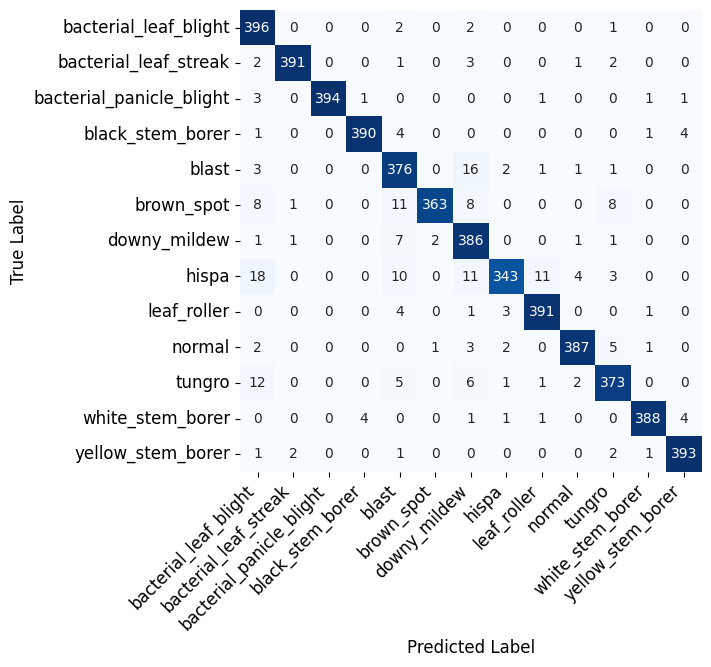

[[396   0   0   0   2   0   2   0   0   0   1   0   0]
 [  2 391   0   0   1   0   3   0   0   1   2   0   0]
 [  3   0 394   1   0   0   0   0   1   0   0   1   1]
 [  1   0   0 390   4   0   0   0   0   0   0   1   4]
 [  3   0   0   0 376   0  16   2   1   1   1   0   0]
 [  8   1   0   0  11 363   8   0   0   0   8   0   0]
 [  1   1   0   0   7   2 386   0   0   1   1   0   0]
 [ 18   0   0   0  10   0  11 343  11   4   3   0   0]
 [  0   0   0   0   4   0   1   3 391   0   0   1   0]
 [  2   0   0   0   0   1   3   2   0 387   5   1   0]
 [ 12   0   0   0   5   0   6   1   1   2 373   0   0]
 [  0   0   0   4   0   0   1   1   1   0   0 388   4]
 [  1   2   0   0   1   0   0   0   0   0   2   1 393]]


In [17]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Get the names of the ten classes
class_names = test_generator.class_indices.keys()

def plot_heatmap(y_true, y_pred, class_names, ax, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, 
        annot=True, 
        square=True, 
        xticklabels=class_names, 
        yticklabels=class_names,
        fmt='d', 
        cmap=plt.cm.Blues,
        cbar=False,
        ax=ax
    )
    #ax.set_title(title, fontsize=16)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=12, rotation=45, ha="right")
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_xlabel('Predicted Label', fontsize=12)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))

plot_heatmap(true_classes, pred_classes, class_names, ax, title="CNN")    

#fig.suptitle("Confusion Matrix Model Comparison", fontsize=12)
#fig.tight_layout()
#fig.subplots_adjust(top=1.25)
plt.show()
cm = confusion_matrix(true_classes, pred_classes)
print(cm)

## Analyze Prediction Distribution
Examine the distribution of predictions across classes to identify any biases or imbalances.

In [18]:
# Reset the generator before prediction
test_generator.reset()

# Use predict() instead of evaluate_generator() since we don't have labels
predictions = model.predict(
    test_generator,
    steps=STEP_SIZE_TEST,
    verbose=1
)

# Get the predicted classes
pred_classes = np.argmax(predictions, axis=1)

# Print prediction summary
print(f"Total predictions made: {len(pred_classes)}")
print(f"Prediction shape: {predictions.shape}")

# Print class distribution
unique_classes, counts = np.unique(pred_classes, return_counts=True)
print("\nPredicted class distribution:")
for cls, count in zip(unique_classes, counts):
    # Get class name from index
    for name, idx in test_generator.class_indices.items():
        if idx == cls:
            class_name = name
            break
    print(f"Class {cls} ({class_name}): {count} images ({count/len(pred_classes)*100:.2f}%)")

5200/5200 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step
Total predictions made: 5200
Prediction shape: (5200, 13)

Predicted class distribution:
Class 0 (bacterial_leaf_blight): 447 images (8.60%)
Class 1 (bacterial_leaf_streak): 395 images (7.60%)
Class 2 (bacterial_panicle_blight): 394 images (7.58%)
Class 3 (black_stem_borer): 395 images (7.60%)
Class 4 (blast): 421 images (8.10%)
Class 5 (brown_spot): 366 images (7.04%)
Class 6 (downy_mildew): 437 images (8.40%)
Class 7 (hispa): 352 images (6.77%)
Class 8 (leaf_roller): 406 images (7.81%)
Class 9 (normal): 396 images (7.62%)
Class 10 (tungro): 396 images (7.62%)
Class 11 (white_stem_borer): 393 images (7.56%)
Class 12 (yellow_stem_borer): 402 images (7.73%)


## Generate Prediction Labels
Convert numeric class predictions to human-readable labels and calculate value counts.

In [19]:
predicted_class_indices=np.argmax(pred,axis=1)
labels = (train_generator.class_indices)

labels = (train_generator.class_indices)
labels = dict((v,k) for k,v in labels.items())
predictions = [labels[k] for k in predicted_class_indices]

pd.Series(predictions).value_counts()

bacterial_leaf_blight       447
downy_mildew                437
blast                       421
leaf_roller                 406
yellow_stem_borer           402
normal                      396
tungro                      396
bacterial_leaf_streak       395
black_stem_borer            395
bacterial_panicle_blight    394
white_stem_borer            393
brown_spot                  366
hispa                       352
Name: count, dtype: int64

## Create Submission File
Generate a CSV submission file with image IDs and predicted labels.

In [20]:
filenames=test_generator.filenames

results=pd.DataFrame({"image_id":filenames,
                      "label":predictions})
results.image_id = results.image_id.str.replace('./', '')
results.to_csv("submission.csv",index=False)
results.head()

,image_id,label
0,bacterial_leaf_blight/PDD00002_001.jpg,bacterial_leaf_blight
1,bacterial_leaf_blight/PDD00002_003.jpg,bacterial_leaf_blight
2,bacterial_leaf_blight/PDD00005_002.jpg,bacterial_leaf_blight
3,bacterial_leaf_blight/PDD00005_004.jpg,bacterial_leaf_blight
4,bacterial_leaf_blight/PDD00006_003.jpg,bacterial_leaf_blight


## Finish Weights & Biases Run
Close the Weights & Biases tracking session.

In [21]:
wandb.finish()

accuracy,▁▆▅▇▆▆▇▇▇▇▇▇▇█▇▇▇█▇▇▇▆█▇█████▇████
loss,█▃▄▂▃▄▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▂▁▂▁▁▁▁▁▂▁▁▁▁
val_accuracy,▃▁▅▅▅▆▆▇▆▆▆▇▆▇▇█▇▇▇▇▆▆▇█▇▇▆▇▇▇▇▆▇▇
val_loss,▇█▅▆▄▃▄▂▄▃▃▃▃▃▃▁▃▂▃▁▃▄▃▁▃▃▄▂▃▁▃▅▃▃
accuracy,1
loss,0.01084
val_accuracy,0.93103
val_loss,0.22878
